# Report

## Introduction / Problem Statement
The goal was to build a movie recommendation system from the MovieLens data. The task was defined as returning five relevant recommendations for a given input movie. The problem was treated as a content-based recommendation problem in which each movie was represented by metadata and aggregated user information rather than by the raw tables directly. In Geron's terminology, this is closer to an instance-based retrieval setting than to supervised classification or regression, while the diversification step can be described as an unsupervised clustering step (Geron, 2025).

## Data Analysis (EDA)
The dataset consisted of *movies.csv*, *ratings.csv*, and *tags.csv*, linked through *movieId*. A movie-level table was therefore built so that genres, aggregated ratings, and aggregated tags could be stored in one row per movie. The EDA showed that ratings were widely available, while tags were more unevenly distributed. Because the models depends on *tag_text*, the modeling table was filtered to movies that had both at least one rating and at least one tag. This reduced coverage, but it produced a cleaner feature space for the final recommender.

The figure below shows why filtering to movies with both ratings and tags was reasonable. Ratings had broad coverage, but tag coverage was clearly more limited. Because the final recommender depends on *tag_text*, movies without tags would have contributed much less information to the clustering step.

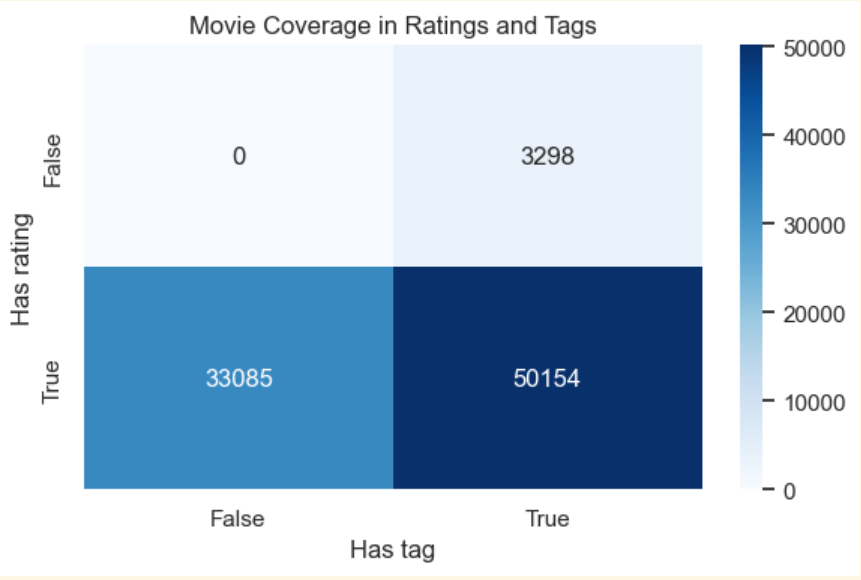

## Model
The final solution combined retrieval, filtering, reranking, and clustering. First, the raw data were loaded, cleaned, and aggregated into columns such as *genres_text*, *tag_text*, *mean_rating*, *rating_count*, and *clean_title*. Movie titles were kept with their release year in the output, but the year was not used as a separate similarity feature.

The baseline retrieval stage used TF-IDF features from *genres_text* and *tag_text* together with *NearestNeighbors*. A larger retrieval pool of 50 movies was collected first. A mild quality filter was then applied with *mean_rating >= 2.0* and *rating_count >= 20*. *mean_rating*-minimum was set to make sure too many movies were not filtered out.    
  
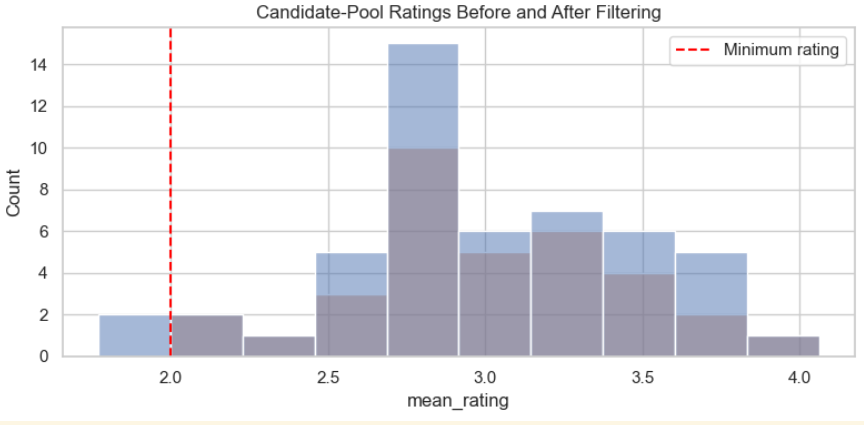
  
The surviving candidates were reranked with a combined score that weighted similarity and normalized mean rating equally. After reranking, the best 20 candidates were passed to *KMeans*, where *k = 5* clusters were used. The final recommendation list was formed by taking the top-ranked movie from each prioritized cluster first, and only using leftovers if fewer than five clusters contributed enough candidates.

No separate train/test split was used. The recommender was fitted on the filtered movie table because the assignment focused on designing and comparing recommendation steps rather than on estimating supervised generalization error (Geron, 2025).

The overall flow of the final recommender is shown below. This figure is placed here because the main design choice of the project was not one isolated estimator, but the combination of several steps.

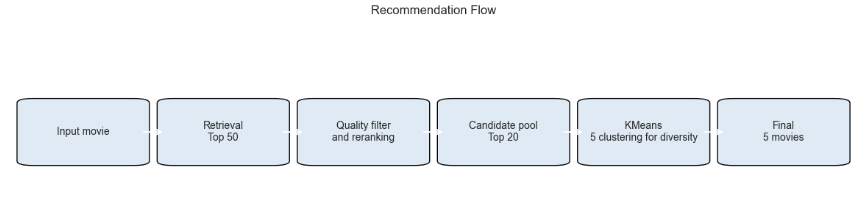

## Results
For the input movie *Silence of the lams*, the retrieval stage produced a relevant but still fairly narrow candidate set. The clustering step then grouped the candidate pool and the final selection drew one strong candidate from each prioritized cluster. This did not guarantee that every individual recommendation was more similar than the baseline top result, but it produced a more varied final list while preserving relevance from the retrieved pool.

The two-dimensional projection below does not represent the true model space exactly, but it gives a useful visual summary of how the candidate pool was structured after retrieval and clustering. Color shows the assigned cluster, point size shows *mean_rating*, and the black ring marks the movies that were actually returned by the recommender.

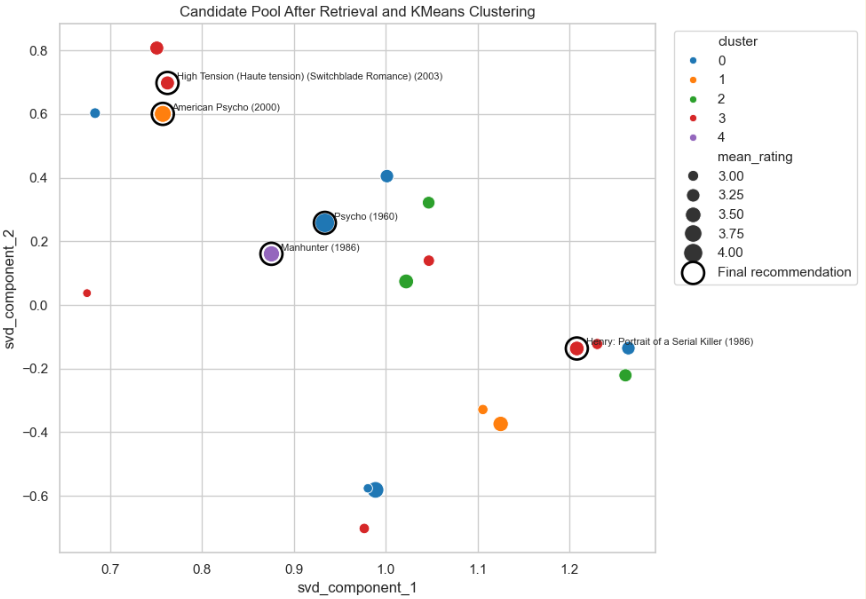

## Discussion
The final model solved the task in a reasonable way, but several limitations remain. The recommender is not personalized at the user level. Instead, it recommends movies similar to a selected input movie based on shared metadata and aggregated user information.

The quality filter improved the stability of the candidate pool, but it also excluded some lower-rated or less frequently rated movies. Likewise, filtering the dataset to movies with both ratings and tags gave the clustering step richer information, but it reduced overall coverage.

The clustering step should also be interpreted carefully. *KMeans* was not used to retrieve the most similar movies directly. It was used to organize an already relevant candidate pool into groups so that the final list could be selected with more variation. This means that the improved model mainly addressed diversity within relevant candidates rather than personalization in the collaborative-filtering sense.

## References
Geron, A. (2025). *Hands-On machine learning with Scikit-Learn and PyTorch: Concepts, tools, and techniques to build intelligent systems*. O'Reilly Media.